# Importing Needed Packages


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

# Reading The Dataset

In [3]:
df = pd.read_csv("HousePrice.csv")
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [5]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


# Data Cleaning

In [7]:
df = df.dropna(subset=['Address'])

In [8]:
df['Area'] = df['Area'].astype(str).str.replace(',', '').astype(float)
df['Area'].sort_values(ascending=False).head(20)

/tmp/ipykernel_1738/3096987784.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Area'] = df['Area'].astype(str).str.replace(',', '').astype(float)


,Area
709,1.616000e+10
1604,8.400000e+09
570,3.310000e+09
2802,2.550000e+09
2171,3.600000e+03
807,1.000000e+03
1694,9.290000e+02
1974,9.000000e+02
573,8.630000e+02
3115,7.500000e+02


In [9]:
Q1 = df['Area'].quantile(0.25)
Q3 = df['Area'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df = df[df['Area'] <= upper_bound]

In [11]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows before dropping: 202
Number of duplicate rows after dropping: 0


In [12]:
print(f"Number of unique addresses: {df['Address'].nunique()}")
print("Top 10 most frequent addresses:")
display(df['Address'].value_counts().head(10))

Number of unique addresses: 187
Top 10 most frequent addresses:


,count
Address,
Punak,148
West Ferdows Boulevard,132
Pardis,123
Shahran,123
Gheitarieh,120
Parand,119
Saadat Abad,109
Shahr-e-Ziba,91
Jeyhoon,88


In [13]:
for col in ['Parking', 'Warehouse', 'Elevator']:
    df[col] = df[col].astype(int)

display(df.head())

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63.0,1,1,1,1,Shahran,1.850000e+09,61666.67
1,60.0,1,1,1,1,Shahran,1.850000e+09,61666.67
2,79.0,2,1,1,1,Pardis,5.500000e+08,18333.33
3,95.0,2,1,1,1,Shahrake Qods,9.025000e+08,30083.33
4,123.0,2,1,1,1,Shahrake Gharb,7.000000e+09,233333.33


# Feature Selection

In [15]:
cdf = df[['Area','Room','Parking','Warehouse','Elevator','Price']]
cdf.head(9)

,Area,Room,Parking,Warehouse,Elevator,Price
0,63.0,1,1,1,1,1.850000e+09
1,60.0,1,1,1,1,1.850000e+09
2,79.0,2,1,1,1,5.500000e+08
3,95.0,2,1,1,1,9.025000e+08
4,123.0,2,1,1,1,7.000000e+09
5,70.0,2,1,1,0,2.050000e+09
6,87.0,2,1,1,1,6.000000e+08
7,59.0,1,1,1,1,2.150000e+09
8,54.0,2,1,1,0,4.930000e+08


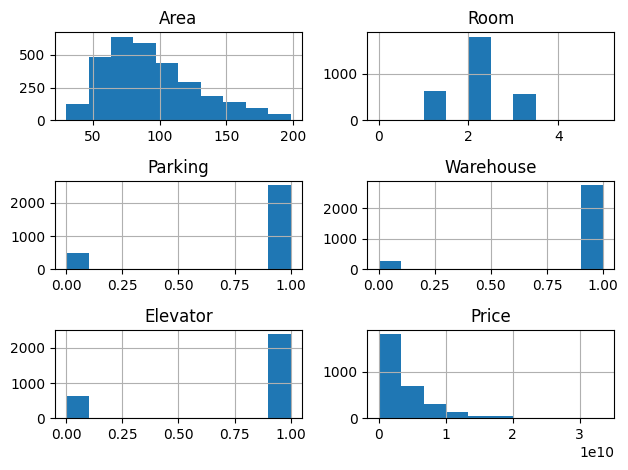

In [16]:
viz = cdf[['Area','Room','Parking','Warehouse','Elevator','Price']]
viz.hist()
plt.tight_layout()
plt.show()

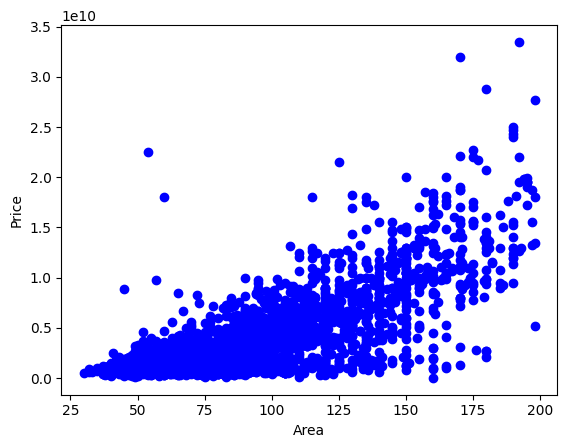

In [17]:
plt.scatter(cdf.Area, cdf.Price, color='blue')
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

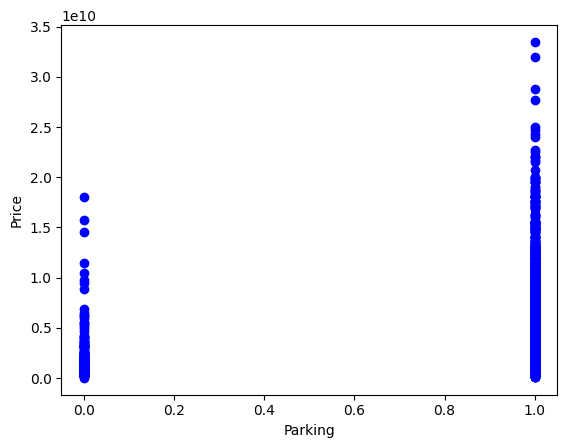

In [19]:
plt.scatter(cdf.Parking, cdf.Price, color='blue')
plt.xlabel("Parking")
plt.ylabel("Price")
plt.show()

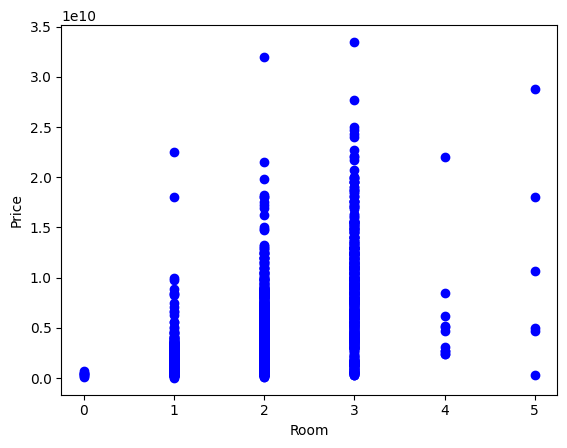

In [20]:
plt.scatter(cdf.Room, cdf.Price, color='blue')
plt.xlabel("Room")
plt.ylabel("Price")
plt.show()

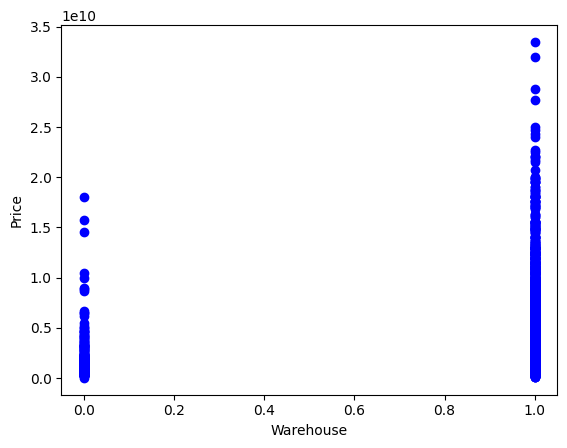

In [23]:
plt.scatter(cdf.Warehouse, cdf.Price, color='blue')
plt.xlabel("Warehouse")
plt.ylabel("Price")
plt.show()

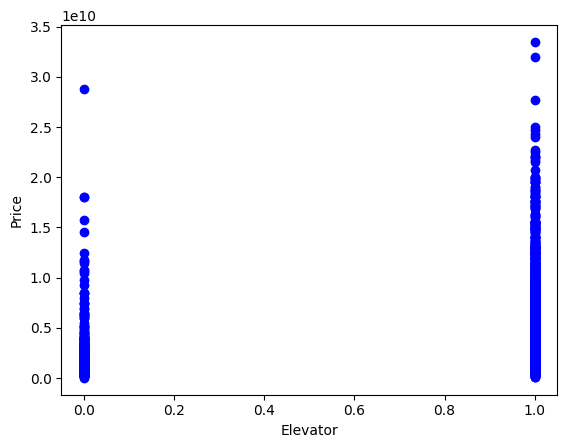

In [24]:
plt.scatter(cdf.Elevator, cdf.Price, color='blue')
plt.xlabel("Elevator")
plt.ylabel("Price")
plt.show()

# Splitting Train/Test Datas

In [25]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]
print (msk)
print (~msk)
print (cdf)
print (train)
print (test)

[False  True  True ... False False  True]
[ True False False ...  True  True False]
       Area  Room  Parking  Warehouse  Elevator         Price
0      63.0     1        1          1         1  1.850000e+09
1      60.0     1        1          1         1  1.850000e+09
2      79.0     2        1          1         1  5.500000e+08
3      95.0     2        1          1         1  9.025000e+08
4     123.0     2        1          1         1  7.000000e+09
...     ...   ...      ...        ...       ...           ...
3473   63.0     1        1          1         0  1.890000e+09
3474   86.0     2        1          1         1  3.500000e+09
3475   83.0     2        1          1         1  6.800000e+09
3477  105.0     2        1          1         1  5.600000e+09
3478   82.0     2        0          1         1  3.600000e+08

[3017 rows x 6 columns]
       Area  Room  Parking  Warehouse  Elevator         Price
1      60.0     1        1          1         1  1.850000e+09
2      79.0     2      

# MultipleLinearRegression Model

In [26]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x = np.asanyarray(train[['Area','Room','Parking','Warehouse','Elevator']])
y = np.asanyarray(train[['Price']])
regr.fit (x, y)
print ('Coefficients: ', regr.coef_)
print ('Coefficients: ', regr.intercept_)

Coefficients:  [[ 9.62881382e+07 -8.91166716e+08  5.76452988e+08  3.29894749e+08
   1.39335602e+08]]
Coefficients:  [-4.13315823e+09]


# Prediction Using MultipleLinearRegression

In [31]:
x = np.asanyarray(test[['Area','Room','Parking','Warehouse','Elevator']])
y = np.asanyarray(test[['Price']])
y_hat= regr.predict(x)

print("Residual sum of squares: %.2f"
      % np.mean((y_hat - y) ** 2))

print('Variance score: %.2f' % regr.score(x, y))

Residual sum of squares: 6193275624699320320.00
Variance score: 0.55


# Polynomial Regression


In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

x_train_poly = train[['Area','Room','Parking','Warehouse','Elevator']]
y_train_poly = train[['Price']]

x_test_poly = test[['Area','Room','Parking','Warehouse','Elevator']]
y_test_poly = test[['Price']]

poly = PolynomialFeatures(degree=2)
x_train_poly_transformed = poly.fit_transform(x_train_poly)

poly_regr = linear_model.LinearRegression()
poly_regr.fit(x_train_poly_transformed, y_train_poly)

print ('Polynomial Coefficients: ', poly_regr.coef_)
print ('Polynomial Intercept: ', poly_regr.intercept_)

Polynomial Coefficients:  [[ 0.00000000e+00 -8.49790225e+07  8.57244317e+08 -6.54694843e+08
   1.35956047e+08 -3.02703818e+08  6.74339370e+05 -6.74119035e+06
   1.86572388e+07 -8.94815825e+06  4.03350979e+07  1.03765382e+08
   1.38496500e+08  3.25642596e+07 -1.56904031e+09 -6.54694843e+08
   4.42171977e+08  6.13808760e+08  1.35956047e+08  4.60703946e+08
  -3.02703818e+08]]
Polynomial Intercept:  [3.00469484e+09]


# Evaluation of Polynomial Regression Model


In [29]:
from sklearn.metrics import r2_score

x_test_poly_transformed = poly.transform(x_test_poly)
y_hat_poly = poly_regr.predict(x_test_poly_transformed)

print("Residual sum of squares (MSE): %.2f"
      % np.mean((y_hat_poly - y_test_poly) ** 2))

print("Explained variance score (R2 Score): %.2f" % r2_score(y_test_poly, y_hat_poly))

Residual sum of squares (MSE): 5285448696114420736.00
Explained variance score (R2 Score): 0.62


# Comparing Model Performance


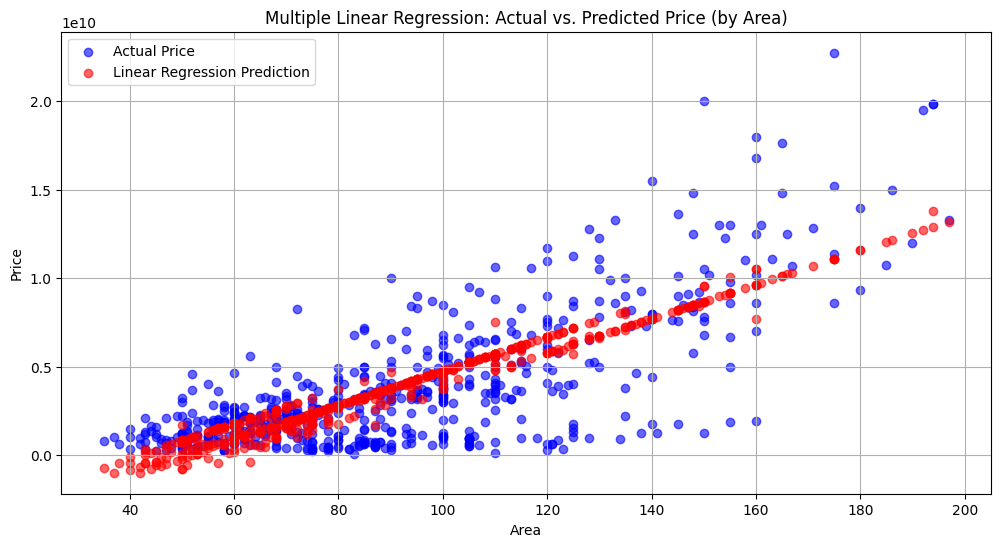

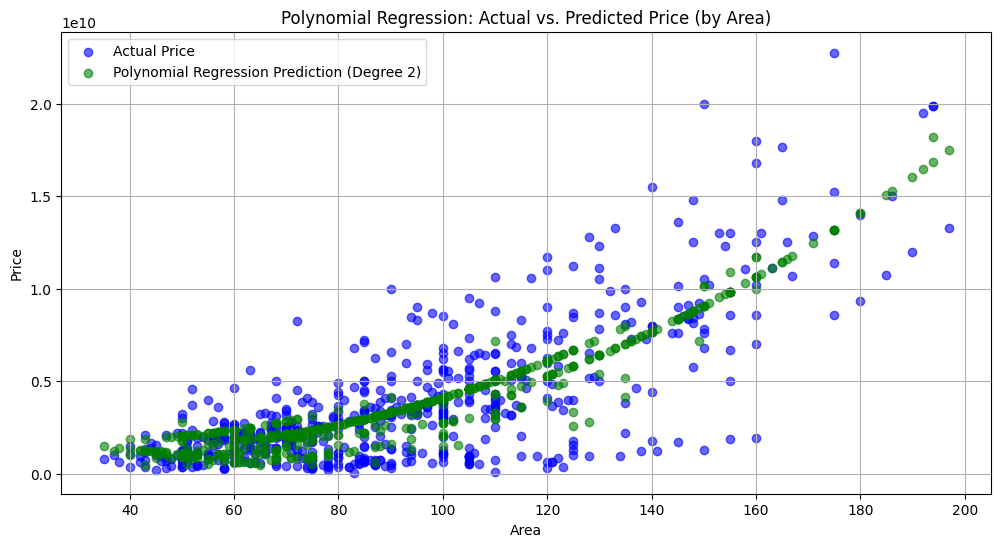

In [30]:
import matplotlib.pyplot as plt

# Prepare data for plotting
x_area_test = np.asanyarray(test[['Area']])
y_actual = np.asanyarray(test[['Price']])

# --- Plot for Multiple Linear Regression ----
plt.figure(figsize=(12, 6))
plt.scatter(x_area_test, y_actual, color='blue', label='Actual Price', alpha=0.6)
plt.scatter(x_area_test, y_hat, color='red', label='Linear Regression Prediction', alpha=0.6)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Multiple Linear Regression: Actual vs. Predicted Price (by Area)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Polynomial Regression ----
# Re-predict using the polynomial features for the test set 'Area' to align with the plot
# We'll need to transform the original test features into polynomial features again for plotting consistency
poly_features_for_plot = poly.fit_transform(x_area_test) # Using just 'Area' for this plot's X-axis
poly_y_hat_area_plot = poly_regr.predict(poly.fit_transform(test[['Area','Room','Parking','Warehouse','Elevator']])) # Use all features for prediction


plt.figure(figsize=(12, 6))
plt.scatter(x_area_test, y_actual, color='blue', label='Actual Price', alpha=0.6)

# To plot the polynomial prediction curve more smoothly, we can predict over a range of 'Area' values.
# However, for comparing individual predictions, we'll plot the y_hat_poly against x_area_test (which corresponds to x_test_poly)
plt.scatter(x_area_test, y_hat_poly, color='green', label='Polynomial Regression Prediction (Degree 2)', alpha=0.6)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Polynomial Regression: Actual vs. Predicted Price (by Area)")
plt.legend()
plt.grid(True)
plt.show()